In [1]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import torchvision
from torch import Tensor

device = "cuda"

In [2]:
import os
import hashlib
import zipfile
import requests

# url = "http://d2l-data.s3-accelerate.amazonaws.com/banana-detection.zip"
# sha1_hash = "5de26c8fce5ccdea9f91267273464dc968d20d72"

# os.makedirs("datasets", exist_ok=True)
# zip_path = os.path.join("data", "banana-detection.zip")
# extract_dir = "datasets"

# # 다운로드
# if not os.path.exists(zip_path):
#     response = requests.get(url, stream=True)
#     response.raise_for_status()

#     with open(zip_path, "wb") as f:
#         for chunk in response.iter_content(chunk_size=1024 * 1024):
#             if chunk:
#                 f.write(chunk)

# # SHA-1 검증
# sha1 = hashlib.sha1()
# with open(zip_path, "rb") as f:
#     for chunk in iter(lambda: f.read(1024 * 1024), b""):
#         sha1.update(chunk)

# if sha1.hexdigest() != sha1_hash:
#     raise ValueError("다운로드한 파일의 SHA-1 해시가 일치하지 않습니다.")

# # 압축 해제
# with zipfile.ZipFile(zip_path, "r") as zip_ref:
#     zip_ref.extractall(extract_dir)

# dataset_path = os.path.join(extract_dir, "banana-detection")
# print(f"데이터셋 경로: {dataset_path}")

In [3]:
def read_data_bananas(is_train=True, data_dir=None):
    """바나나 탐지 데이터셋의 이미지와 정규화된 라벨을 읽는다."""
    if data_dir is None:
        candidates = [
            os.path.join("datasets", "banana-detection"),
            os.path.join("..", "..", "datasets", "banana-detection"),
        ]
        data_dir = next((path for path in candidates if os.path.isdir(path)), None)
        if data_dir is None:
            raise FileNotFoundError(
                "banana-detection 데이터셋을 찾을 수 없습니다. "
                "data_dir에 데이터셋 경로를 지정하세요."
            )

    split = "bananas_train" if is_train else "bananas_val"
    split_dir = os.path.join(data_dir, split)
    csv_data = pd.read_csv(os.path.join(split_dir, "label.csv"))

    images, targets = [], []
    for row in csv_data.itertuples(index=False):
        image = torchvision.io.read_image(
            os.path.join(split_dir, "images", row.img_name)
        )
        _, height, width = image.shape
        images.append(image)
        targets.append([
            float(row.label),
            row.xmin / width,
            row.ymin / height,
            row.xmax / width,
            row.ymax / height,
        ])

    return images, torch.tensor(targets, dtype=torch.float32).unsqueeze(1)

In [ ]:
from torch.utils.data import Dataset, DataLoader

class BananasDataset(Dataset):
    def __init__(self, is_train:bool):
        self.features, self.labels = read_data_bananas(is_train)
        print('read ' + str(len(self.features)) + (f' training examples' if
              is_train else f' validation examples'))
    
    def __getitem__(self, idx):
        return (self.features[idx].float(), self.labels[idx])
    
    def __len__(self):
        return len(self.features)

In [ ]:
from study.d_01object_detect.ssd import SSD

batch_size:int = 32
edge_size:int = 256

train_loader = DataLoader(BananasDataset(True), batch_size, shuffle=True, pin_memory=True)
test_loader = DataLoader(BananasDataset(False), batch_size, pin_memory=True)

model = SSD().to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=5e-4)

read 1000 training examples
read 100 validation examples


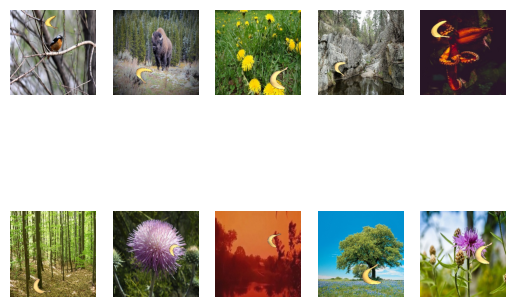

In [7]:
from matplotlib.axes import Axes

batch = next(iter(train_loader))

fig, axes = plt.subplots(2,5)
axes = axes.flatten()

for image, ax in zip(images, axes):
    img = image.permute(1,2,0).cpu()
    ax.imshow(img)
    ax.axis("off")

plt.show()